In [434]:
import numpy as np
import pandas_ta as ta
import pandas as pd
from datetime import time
from matplotlib import pyplot as plt
#can plot candlestick charts
import mplfinance as mpf

#import data
rawData = pd.read_csv("DBNQOHLCV5M.csv")
rawData["Date"] = pd.to_datetime(rawData["Date"]).dt.tz_localize(None)

#format data to be from 2016-2026 and only between 9:30 and 11:30
NQ = rawData[
    (rawData["Date"].dt.time >= pd.to_datetime("13:30").time()) &
    (rawData["Date"].dt.time <= pd.to_datetime("19:55").time())
]
##NQ = NQ[NQ["time"] >= "2016-08-14 13:30:00"]

#change the labels
NQ = NQ.rename(columns={
    "open" : "Open",
    "high" : "High",
    "low" : "Low",
    "close" : "Close"
})
#Changes the index of the Dataframe to the "Date" value
NQ = NQ.set_index("Date")


#Drop corrupt data
# 1. flag anomalous bars using a GLOBAL median/MAD baseline
rng = NQ.High - NQ.Low
global_med = rng.median()
global_mad = (rng - global_med).abs().median()
bad_bar = rng > (global_med + 15 * global_mad)

# 2. find days where too many bars are flagged
daily_bad_pct = bad_bar.groupby(NQ.index.date).mean() * 100
bad_days = daily_bad_pct[daily_bad_pct > 5].index  # threshold: >5% of bars on that day

print(f"Excluding {len(bad_days)} corrupted days: {list(bad_days)}")

# 3. drop those calendar days entirely
NQ= NQ[~pd.Series(NQ.index.date, index=NQ.index).isin(bad_days)]

NQ

KeyboardInterrupt: 

In [ ]:
"""#5M ORB
balance = 25000
TP_ratio = 2
trade_open = False
contract_size = 2
wins_5m = 0
loss_5m = 0

#use to track trades and results
trades_list_5m = []
balance_history_5m = []

close_gap = 1

ORB_high = None
ORB_low = None


- set the orb high and low
- iterate each day until 11 where everything will reset
- look for a break of orb h/l
for i, row in NQ.iterrows():
    if(i.hour == 13 and i.minute == 30):
        ORB_high = row.High
        ORB_low = row.Low
    #check if a trade can be opened
    if (i.hour < 15) and (not trade_open) and (ORB_high is not None) and (ORB_low is not None):
        if row.Close > ORB_high + close_gap:
            #breakout of high
            entry_price = row.Close
            entry_time = i.time()
            entry_index = i
            trade_open = True
            position = "long"
            SL = ORB_high
            TP = entry_price + ((entry_price - SL) * TP_ratio)
        elif row.Close < ORB_low + close_gap:
            #breakout of low
            entry_price = row.Close
            entry_time = i.time()
            entry_index = i
            trade_open = True
            position = "short"
            SL = ORB_low
            TP = entry_price - ((SL - entry_price) * TP_ratio)
    #when a trade is open
    if trade_open and i != entry_index:
        #check if SL or TP is hit
        if(i.hour == 19 and i.minute == 55):
            #If it hits 4:00, all trades close
            if position == "long":
                if row.High >= TP:
                    trade_open = False
                    exit_price = TP
                    wins_5m += 1
                elif row.Low <= SL:
                    trade_open = False
                    exit_price = SL
                    loss_5m += 1
                elif row.Close >= entry_price:
                    trade_open = False
                    exit_price = row.Close
                    wins_5m += 1
                elif row.Close < entry_price:
                    trade_open = False
                    exit_price = row.Close
                    loss_5m += 1
            elif position == "short":
                if row.Low <= TP:
                    trade_open = False
                    exit_price = TP
                    wins_5m += 1
                elif row.High >= SL:
                    trade_open = False
                    exit_price = SL
                    loss_5m += 1
                elif row.Close <= entry_price:
                    trade_open = False
                    exit_price = row.Close
                    wins_5m += 1
                elif row.Close > entry_price:
                    trade_open = False
                    exit_price = row.Close
                    loss_5m += 1  
        elif position == "long":
            if row.High >= TP:
                trade_open = False
                exit_price = TP
                wins_5m += 1
            elif row.Low <= SL:
                trade_open = False
                exit_price = SL
                loss_5m += 1
        elif position == "short":
            if row.Low <= TP:
                trade_open = False
                exit_price = TP
                wins_5m += 1
            elif row.High >= SL:
                trade_open = False
                exit_price = SL
                loss_5m += 1

        #calculate PnL and balance
        if not trade_open:
            exit_time = i.time()
            if position == "long":
                pnl = (exit_price - entry_price) * 2 * contract_size
            elif position == "short":
                pnl = (entry_price - exit_price) * 2 * contract_size
            balance += pnl

            #Store trades taken in a new list
            trade = [entry_time, entry_price, exit_time, exit_price, position, pnl, balance]
            trades_list_5m.append(trade)
    #Track balance
    #Balance is out of the loop so it has a value corresponding to every "Date" in the dataframe
    balance_history_5m.append(balance) 
    
    """

'#5M ORB\nbalance = 25000\nTP_ratio = 2\ntrade_open = False\ncontract_size = 2\nwins_5m = 0\nloss_5m = 0\n\n#use to track trades and results\ntrades_list_5m = []\nbalance_history_5m = []\n\nclose_gap = 1\n\nORB_high = None\nORB_low = None\n\n\n- set the orb high and low\n- iterate each day until 11 where everything will reset\n- look for a break of orb h/l\nfor i, row in NQ.iterrows():\n    if(i.hour == 13 and i.minute == 30):\n        ORB_high = row.High\n        ORB_low = row.Low\n    #check if a trade can be opened\n    if (i.hour < 15) and (not trade_open) and (ORB_high is not None) and (ORB_low is not None):\n        if row.Close > ORB_high + close_gap:\n            #breakout of high\n            entry_price = row.Close\n            entry_time = i.time()\n            entry_index = i\n            trade_open = True\n            position = "long"\n            SL = ORB_high\n            TP = entry_price + ((entry_price - SL) * TP_ratio)\n        elif row.Close < ORB_low + close_gap:\n

In [ ]:
#15m ORB
#define variables
balance2 = 25000
TP_ratio = 2
trade_open = False
contract_size = 1
wins_15m = 0
loss_15m = 0

#use to track trades and results
trades_list_15m = []
balance_history_15m = []
graphed_balance_history = []
riskFreeRate = []

ORB_high = None
ORB_low = None
tempORB_high2 = float("-inf")
tempORB_low2 = float("inf")
yesterdate = None

SLdivider = 650

""" 
- set the orb high and low
- iterate each day until 2:55 PM est where everything will reset
- look for a break of orb h/l
"""
for i, row in NQ.iterrows():
    if i.date() != yesterdate:
        ORB_high = None
        ORB_low = None
        trade_taken = False
        tempORB_high = float("-inf")
        tempORB_low = float("inf")
        yesterdate = i.date()
    if(i.hour == 13 and (i.minute == 30 or i.minute == 35 or i.minute == 40)):
        if(row.High > tempORB_high):
            tempORB_high = row.High
        if(row.Low < tempORB_low):
            tempORB_low = row.Low
        if(i.minute == 40):
            ORB_high = tempORB_high
            ORB_low = tempORB_low
            ORB_Range = ORB_high - ORB_low
    #check if a trade can be opened
    if (
        ((i.hour < 15) or (i.hour == 15 and i.minute < 15))
        and (not trade_open) 
        and (ORB_high is not None) 
        and (ORB_low is not None) 
        and (i.month_name() != "June") 
        and (ORB_Range < 250)
        and (row.Volume > 5000)
        ):
        if row.Close > ORB_high:
            #breakout of high
            entry_price = row.Close
            entry_time = i.time()
            entry_index = i
            trade_open = True
            position = "long"
            SL = ORB_high - ORB_Range/SLdivider
            TP = entry_price + ((entry_price - SL) * TP_ratio)
        elif row.Close < ORB_low:
            #breakout of low
            entry_price = row.Close
            entry_time = i.time()
            entry_index = i
            trade_open = True
            position = "short"
            SL = ORB_low + ORB_Range/SLdivider
            TP = entry_price - ((SL - entry_price) * TP_ratio)
    #when a trade is open
    if trade_open and i != entry_index:
        #check if SL or TP is hit 
        if(i.hour == 19 and i.minute == 55):
            #If it hits 4:00, all trades close
            if position == "long":
                if row.High >= TP:
                    trade_open = False
                    exit_price = TP
                    wins_15m += 1
                elif row.Low <= SL:
                    trade_open = False
                    exit_price = SL
                    loss_15m += 1
                elif row.Close >= entry_price:
                    trade_open = False
                    exit_price = row.Close
                    wins_15m += 1
                elif row.Close < entry_price:
                    trade_open = False
                    exit_price = row.Close
                    loss_15m += 1
            elif position == "short":
                if row.Low <= TP:
                    trade_open = False
                    exit_price = TP
                    wins_15m += 1
                elif row.High >= SL:
                    trade_open = False
                    exit_price = SL
                    loss_15m += 1
                elif row.Close <= entry_price:
                    trade_open = False
                    exit_price = row.Close
                    wins_15m += 1
                elif row.Close > entry_price:
                    trade_open = False
                    exit_price = row.Close
                    loss_15m += 1
        elif position == "long":
            if row.High >= TP:
                trade_open = False
                exit_price = TP
                wins_15m += 1
            elif row.Low <= SL:
                trade_open = False
                exit_price = SL
                loss_15m += 1
        elif position == "short":
            if row.Low <= TP:
                trade_open = False
                exit_price = TP
                wins_15m += 1
            elif row.High >= SL:
                trade_open = False
                exit_price = SL
                loss_15m += 1

        #calculate PnL and balance
        #account for commissions by subtracting $1.00
        if not trade_open:
            exit_time = i.time()
            if position == "long":
                pnl = ((exit_price - entry_price) * 2 * contract_size) - 1
            elif position == "short":
                pnl = ((entry_price - exit_price) * 2 * contract_size) - 1
            balance2 += pnl
            returns = pnl/balance2

            #Store trades taken in a new list
            trade = [entry_time, entry_price, exit_time, exit_price, position, pnl, returns, balance2, ORB_Range]
            trades_list_15m.append(trade)
    #Track balance for each row (graphing purposes)
    graphed_balance_history.append(balance2)   

    #Balance is out of the loop so it has a value corresponding to every "Date" in the dataframe
    if (i.hour == 19 and i.minute == 55):
        balance_history_15m.append(balance2)
        riskFreeRate.append(row.RiskFreeRate)

In [ ]:
#Create a dataframe from the data
#trades_5m = pd.DataFrame(trades_list_5m, columns=["Entry_time", "Entry_price", "Exit_time", "Exit_price", "Position", "PnL", "Balance"])
trades_15m = pd.DataFrame(trades_list_15m, columns=["Entry_time", "Entry_price", "Exit_time", "Exit_price", "Position", "PnL", "Return", "Balance", "ORB_Range"])

#Create a balance_history dataframe
running_peak = []
peak = 0
drawdown = []
for balance in balance_history_15m:
    if balance > peak:
        peak = balance
    running_peak.append(peak)

balance_history = pd.DataFrame({
    "Balance" : balance_history_15m,
    "Running_Peak" : running_peak,
    "RiskFreeRate" : riskFreeRate
})
balance_history["Drawdown"] = (balance_history["Balance"] - balance_history["Running_Peak"]) / balance_history["Running_Peak"]
worstDD = balance_history["Drawdown"].min()
balance_history["Daily_Return"] = (balance_history["Balance"] / balance_history["Balance"].shift(1)) - 1
balance_history["RiskFreeRate"] = balance_history["RiskFreeRate"]/252
balance_history["Excess_Return"] = balance_history["Daily_Return"] - balance_history["RiskFreeRate"]
meanExcessReturn = balance_history["Excess_Return"].mean()
dailyReturnSTD = balance_history["Daily_Return"].std()

#Calculate stats
win_rate_15m = wins_15m / (wins_15m+loss_15m) * 100
loss_rate_15m = loss_15m/ (loss_15m + wins_15m) * 100
avg_win = trades_15m.loc[trades_15m.PnL > 0, "PnL"].mean()
avg_loss = trades_15m.loc[trades_15m.PnL < 0, "PnL"].mean()
Percent_increase_15m = ((balance_history_15m[-1] - 25000)/ 25000) * 100
expectancy = ((win_rate_15m/100)* (avg_win)) + ((loss_rate_15m/100) * (avg_loss))
profit_factor = trades_15m.loc[trades_15m.PnL > 0, "PnL"].sum() / abs(trades_15m.loc[trades_15m.PnL < 0, "PnL"].sum())
sharpe = (meanExcessReturn/dailyReturnSTD) * np.sqrt(252)


print("15 Minute Winrate ", round(win_rate_15m, 3))
print("15 Minute Lossrate", round(loss_rate_15m, 3))
print("Trades taken: ", len(trades_15m))
print("15 Minute Total percent increase: ", Percent_increase_15m)
print("Average win", avg_win)
print("Average loss", avg_loss)
print("Expectancy R: ", round(expectancy,3))
print("Profit Factor: ", round(profit_factor,3))
print("Worst Drawdown: ", worstDD * 100)
print("Sharpe: ", sharpe)


15 Minute Winrate  49.079
15 Minute Lossrate 50.921
Trades taken:  1520
15 Minute Total percent increase:  64.99907999999891
Average win 83.5945741389974
Average loss -59.57594613396943
Expectancy R:  10.691
Profit Factor:  1.352
Worst Drawdown:  -4.688626112017427
Sharpe:  1.0293078041781105


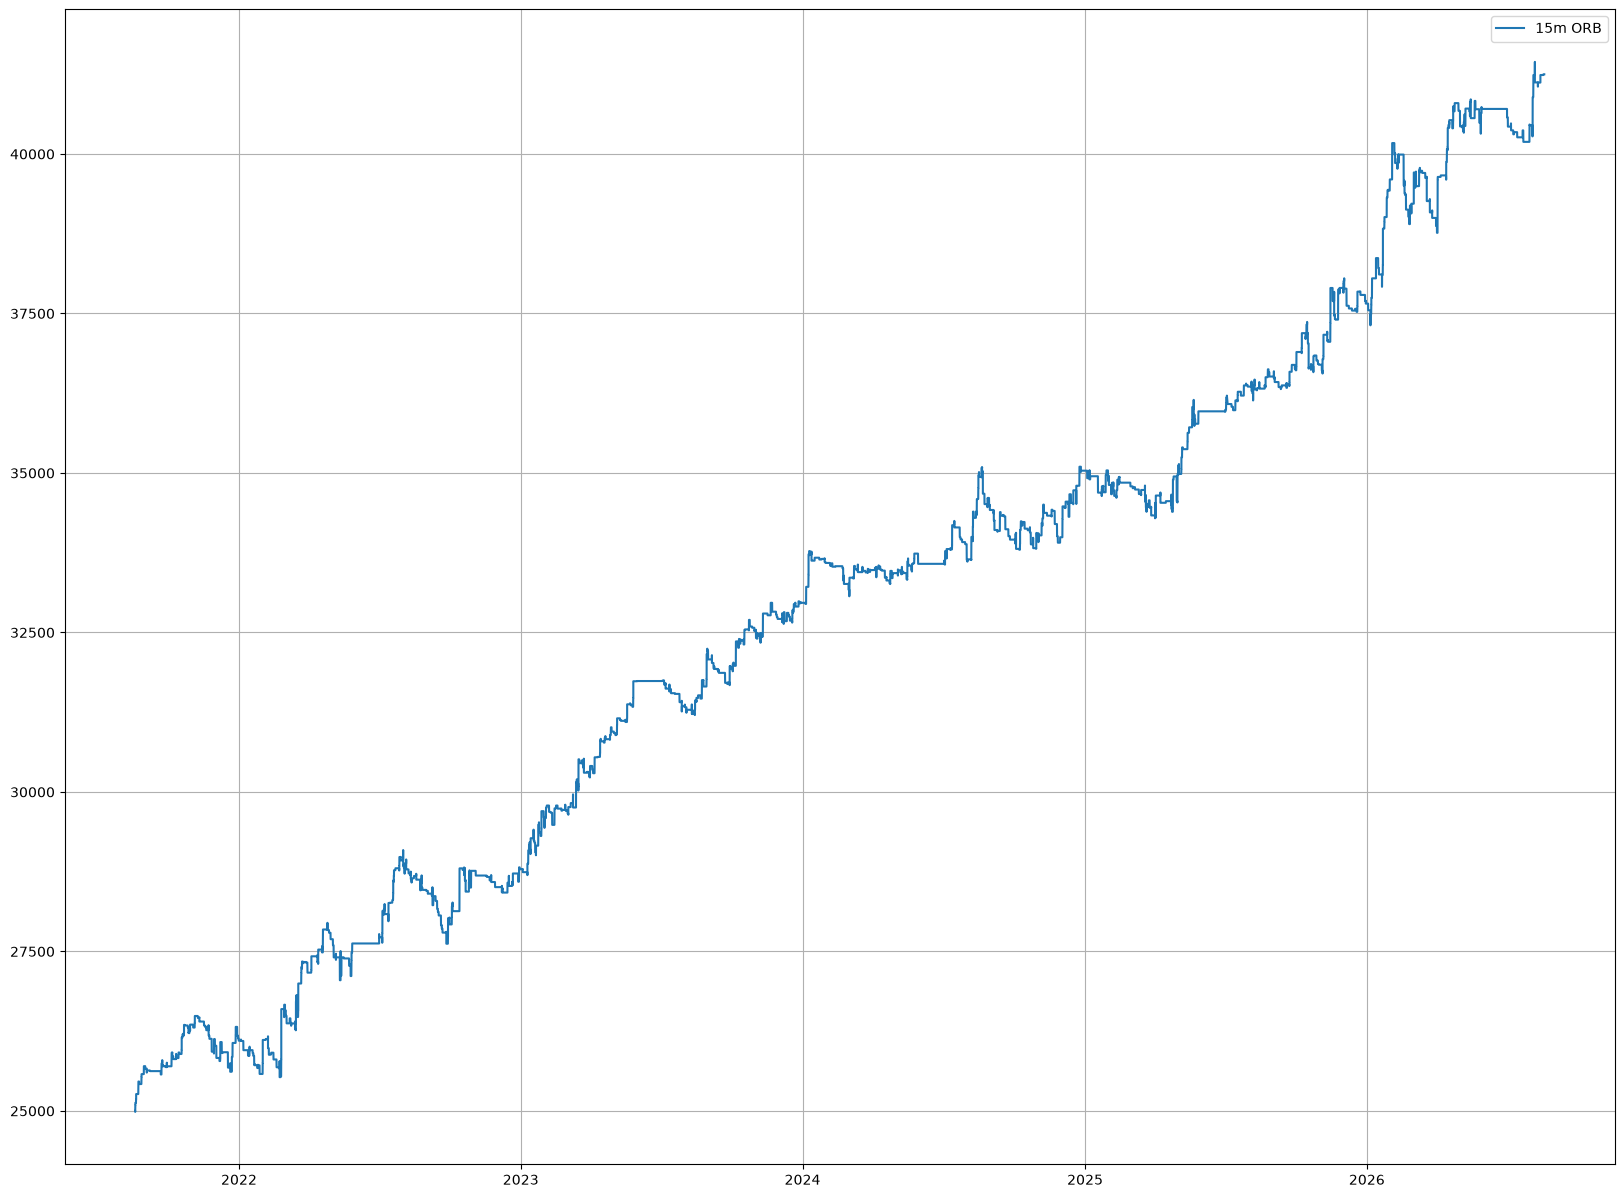

In [ ]:
plt.figure(figsize=(20,15))
plt.plot(NQ.index, graphed_balance_history, label = "15m ORB")
plt.ticklabel_format(style='plain', axis = 'y')
plt.legend()
plt.grid(visible = True)